## Tutorial: Using AR (Adaptive Resampling) with a Custom Model

This notebook is a self-contained tutorial that shows step by step how to plug the AR module into your own example model. It trains the **same custom autoencoder twice** — with **Standard** (uniform) sampling and with **AR** — so you can compare them directly.

To make AR's benefit clear, two design choices matter:

1. **A custom autoencoder** with encoding and decoding modules.
2. **A per-cell-type (macro-averaged) evaluation.** AR helps *rare* cell types at a tiny cost to abundant ones. A plain population-averaged loss is dominated by abundant cells and hides this — so we also report the macro average and the error on the rarest types, where AR's advantage shows up.

| | Sampling |
|---|---|
| **Standard** | Uniform random mini-batches every epoch |
| **AR** | Weighted sampling — cells in low-density latent regions are upweighted |


#### What you need from your model

AR only requires that your model exposes a latent representation at the end of each epoch. Concretely:

```python
reconstruction, z = model(x)   # z is the latent code used by AR
```


### Imports

In [32]:
import sys, os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib as mpl
import scanpy as sc
from sklearn.model_selection import train_test_split

sys.path.insert(0, os.path.abspath('.'))
from scripts.AR_resampling_weight_calculator import calculate_resampling_weights

### Load and preprocess data

We use a small, ready-made subset of the **cross-species dataset** (Hagai et al.), provided as `data/species_for_AR_example.h5ad`. It contains ~5,000 cells × 2,000 highly variable genes, grouped into 15 Louvain cell populations. The expression matrix is already library-size normalized and log1p-transformed, so no further preprocessing is needed.

In [ ]:

adata = sc.read_h5ad("data/species_for_AR_example.h5ad")
print(f"Small, imbalanced species subset shape: {adata.shape}")
print("\nCell population distribution:")
print(adata.obs["str_labels"].value_counts().to_string())
imb = adata.obs["str_labels"].value_counts()
print(f"\nImbalance ratio (largest / smallest): {imb.max() / imb.min():.0f}x")

Small, imbalanced species subset shape: (5085, 2000)

Cell population distribution:
str_labels
clust_0     2500
clust_1     1200
clust_2      600
clust_3      300
clust_7      150
clust_8       90
clust_9       60
clust_4       45
clust_5       35
clust_6       28
clust_10      22
clust_13      18
clust_11      15
clust_12      12
clust_14      10

Imbalance ratio (largest / smallest): 250x


In [34]:
X = adata.X.toarray().astype("float32")
y = adata.obs["str_labels"].to_numpy()

# Stratified split keeps the same cell-type proportions (incl. rare types) in train and val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train)
X_val_t   = torch.tensor(X_val)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")
print("\nValidation cell-type counts:")
print(pd.Series(y_val).value_counts().to_string())

Train: (4068, 2000)  |  Val: (1017, 2000)

Validation cell-type counts:
clust_0     500
clust_1     240
clust_2     120
clust_3      60
clust_7      30
clust_8      18
clust_9      12
clust_4       9
clust_5       7
clust_6       6
clust_13      4
clust_10      4
clust_11      3
clust_14      2
clust_12      2


### Define your custom model — a tight-bottleneck autoencoder

The only contract AR imposes is that `forward()` returns `(reconstruction, z)`:

```python
reconstruction, z = model(x)
```

- `x`  — input gene expression tensor of shape `(batch, n_genes)`
- `reconstruction` — model output of shape `(batch, n_genes)` used to compute the loss
- `z`  — latent code of shape `(batch, latent_dim)` used by AR to compute resampling weights

In [ ]:
class CustomAutoencoder(nn.Module):
    """MLP autoencoder.

    A small `latent_dim` and modest `hidden_dim` create an *undercomplete*
    model with limited capacity. This capacity competition is what lets AR's
    rebalancing show up: uniform sampling favors abundant cell types, while AR
    forces the scarce capacity to also cover rare types.

    The only contract AR imposes is that forward() returns (reconstruction, z).
    """

    def __init__(self, input_dim, latent_dim=8, hidden_dim=64, dropout_rate=0.1):
        super().__init__()

        # ── Encoder: maps gene expression → small latent code z ───────────────
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, latent_dim),
        )

        # ── Decoder: reconstructs gene expression from the bottleneck z ────────
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim),  nn.Softplus(),  # non-negative output
        )

    def forward(self, x):
        z    = self.encoder(x)     # latent representation — used by AR
        recon = self.decoder(z)    # reconstruction — used for the loss
        return recon, z            # AR expects exactly this signature

### Hyperparameters

Standard training hyperparameters are grouped separately from the two AR-specific parameters (`BINS` and `SMOOTHING`) so it is easy to see what AR adds.

In [ ]:
# ── Standard hyperparameters ────────────────────────────────────────────────
SEED         = 42
LATENT_DIM   = 8       
HIDDEN_DIM   = 64    
BATCH_SIZE   = 128
NUM_EPOCHS   = 150
LR           = 1e-3
DROPOUT      = 0.1
WEIGHT_DECAY = 1e-4

# ── AR-specific hyperparameters ─────────────────────────────────────────────
# BINS      controls how finely the latent space is discretised for density
#           estimation. Default: 100.
BINS      = 100

# SMOOTHING prevents division by zero in empty histogram bins. 
SMOOTHING = 0.001

# ── Evaluation config ───────────────────────────────────────────────────────
N_RARE_TYPES = 4
rare_types = (
    pd.Series(y_train).value_counts().sort_values().index[:N_RARE_TYPES].tolist()
)
print(f"Rare cell types (smallest {N_RARE_TYPES}): {rare_types}")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Rare cell types (smallest 4): ['clust_14', 'clust_12', 'clust_11', 'clust_13']
Device: cpu


### Training loops — Standard and AR

In [37]:
def per_celltype_mse(model, X_t, labels, device):
    """Mean reconstruction MSE for each cell type.

    Returns a pandas Series indexed by cell type. The *macro* average
    (Series.mean()) weights every cell type equally regardless of size, so it
    reflects how well rare types are reconstructed — unlike the population
    average, which is dominated by abundant types.
    """
    model.eval()
    with torch.no_grad():
        recon, _ = model(X_t.to(device))
        # per-cell MSE across genes
        cell_mse = ((recon - X_t.to(device)) ** 2).mean(dim=1).cpu().numpy()
    return pd.DataFrame({"celltype": labels, "mse": cell_mse}).groupby("celltype")["mse"].mean()


def train_standard(
    model,
    X_train_t,
    X_val_t,
    val_labels,
    num_epochs,
    batch_size,
    lr,
    weight_decay,
    device,
    loss_fn=None,
):
    """Train with uniform random mini-batch sampling (no AR)."""
    if loss_fn is None:
        loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)

    train_losses, val_losses, macro_val_losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon, _ = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(batch)
        train_losses.append(running_loss / len(X_train_t))

        model.eval()
        with torch.no_grad():
            recon_val, _ = model(X_val_t.to(device))
            val_loss = loss_fn(recon_val, X_val_t.to(device)).item()
        val_losses.append(val_loss)
        macro_val_losses.append(per_celltype_mse(model, X_val_t, val_labels, device).mean())

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1:3d}/{num_epochs}]  train={train_losses[-1]:.4f}  "
                  f"val={val_loss:.4f}  macro_val={macro_val_losses[-1]:.4f}")

    return train_losses, val_losses, macro_val_losses


def train_with_AR(
    model,
    X_train_t,
    X_val_t,
    val_labels,
    num_epochs,
    batch_size,
    lr,
    weight_decay,
    device,
    bins=100,
    smoothing_fac=0.001,
    loss_fn=None,
):
    """
    Train `model` with Adaptive Resampling (AR).

    Parameters
    ----------
    model        : nn.Module with signature forward(x) -> (recon, z)
    X_train_t    : torch.Tensor, shape (n_train, n_features)
    X_val_t      : torch.Tensor, shape (n_val,   n_features)
    val_labels   : array-like of cell-type labels for the validation cells
    num_epochs   : int
    batch_size   : int
    lr           : float  — learning rate for Adam
    weight_decay : float  — L2 regularisation coefficient
    device       : torch.device
    bins         : int    — histogram bins for AR density estimation
    smoothing_fac: float  — prevents zero-density bins
    loss_fn      : callable or None — defaults to nn.MSELoss()

    Returns
    -------
    train_losses, val_losses, macro_val_losses : per-epoch loss lists
    """
    if loss_fn is None:
        loss_fn = nn.MSELoss()

    optimizer      = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    n_train        = len(X_train_t)
    steps_per_epoch = n_train // batch_size

    train_losses, val_losses, macro_val_losses = [], [], []
    w = None  # epoch 0 uses uniform sampling (weights=None in random.choices)

    for epoch in range(num_epochs):

        # ── AR Step 1: encode the full training set to obtain latent codes ──
        # Skip on the very first epoch because the model has not yet learned
        # a meaningful latent space — uniform sampling is used instead.
        if epoch > 0:
            model.eval()
            with torch.no_grad():
                _, z = model(X_train_t.to(device))

            # compute per-cell resampling weights
            w = calculate_resampling_weights(
                z.cpu().numpy(),
                bins=bins,
                smoothing_fac=smoothing_fac,
            )

        model.train()
        running_loss = 0.0

        for _ in range(steps_per_epoch):

            # weighted sampling
            idx   = random.choices(range(n_train), weights=w, k=batch_size)
            batch = X_train_t[idx].to(device)

            optimizer.zero_grad()
            recon, _ = model(batch)     # latent z not needed during the update step
            loss = loss_fn(recon, batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_size

        train_losses.append(running_loss / (steps_per_epoch * batch_size))

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            recon_val, _ = model(X_val_t.to(device))
            val_loss = loss_fn(recon_val, X_val_t.to(device)).item()
        val_losses.append(val_loss)
        macro_val_losses.append(per_celltype_mse(model, X_val_t, val_labels, device).mean())

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1:3d}/{num_epochs}]  train={train_losses[-1]:.4f}  "
                  f"val={val_loss:.4f}  macro_val={macro_val_losses[-1]:.4f}")

    return train_losses, val_losses, macro_val_losses

### Train both models and compare

We train two fresh copies of `CustomAutoencoder` with the same random seed so the only difference is the sampling strategy.

In [38]:
print("Standard training")
print("-" * 50)
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

model_std = CustomAutoencoder(
    input_dim=X_train.shape[1],
    latent_dim=LATENT_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout_rate=DROPOUT,
).to(device)

train_std, val_std, macro_std = train_standard(
    model_std,
    X_train_t,
    X_val_t,
    y_val,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    device=device,
)

print(f"\nFinal training loss        : {train_std[-1]:.4f}")
print(f"Final validation loss      : {val_std[-1]:.4f}")
print(f"Final macro validation loss: {macro_std[-1]:.4f}")

Standard training
--------------------------------------------------
  Epoch [ 10/150]  train=0.0941  val=0.0858  macro_val=0.1058
  Epoch [ 20/150]  train=0.0897  val=0.0828  macro_val=0.1018
  Epoch [ 30/150]  train=0.0881  val=0.0818  macro_val=0.1003
  Epoch [ 40/150]  train=0.0874  val=0.0813  macro_val=0.0994
  Epoch [ 50/150]  train=0.0871  val=0.0813  macro_val=0.0995
  Epoch [ 60/150]  train=0.0868  val=0.0810  macro_val=0.0990
  Epoch [ 70/150]  train=0.0867  val=0.0808  macro_val=0.0988
  Epoch [ 80/150]  train=0.0866  val=0.0807  macro_val=0.0983
  Epoch [ 90/150]  train=0.0863  val=0.0806  macro_val=0.0985
  Epoch [100/150]  train=0.0863  val=0.0806  macro_val=0.0985
  Epoch [110/150]  train=0.0863  val=0.0806  macro_val=0.0983
  Epoch [120/150]  train=0.0862  val=0.0805  macro_val=0.0981
  Epoch [130/150]  train=0.0862  val=0.0804  macro_val=0.0980
  Epoch [140/150]  train=0.0860  val=0.0803  macro_val=0.0981
  Epoch [150/150]  train=0.0861  val=0.0803  macro_val=0.0981



In [39]:
print("AR training")
print("-" * 50)
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

model_ar = CustomAutoencoder(
    input_dim=X_train.shape[1],
    latent_dim=LATENT_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout_rate=DROPOUT,
).to(device)

train_ar, val_ar, macro_ar = train_with_AR(
    model_ar,
    X_train_t,
    X_val_t,
    y_val,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    device=device,
    bins=BINS,
    smoothing_fac=SMOOTHING,
)

print(f"\nFinal training loss        : {train_ar[-1]:.4f}")
print(f"Final validation loss      : {val_ar[-1]:.4f}")
print(f"Final macro validation loss: {macro_ar[-1]:.4f}")

AR training
--------------------------------------------------
  Epoch [ 10/150]  train=0.1020  val=0.0863  macro_val=0.1039
  Epoch [ 20/150]  train=0.0994  val=0.0833  macro_val=0.0997
  Epoch [ 30/150]  train=0.0947  val=0.0824  macro_val=0.0989
  Epoch [ 40/150]  train=0.0901  val=0.0819  macro_val=0.0986
  Epoch [ 50/150]  train=0.0919  val=0.0815  macro_val=0.0982
  Epoch [ 60/150]  train=0.0909  val=0.0812  macro_val=0.0978
  Epoch [ 70/150]  train=0.0893  val=0.0808  macro_val=0.0972
  Epoch [ 80/150]  train=0.0909  val=0.0806  macro_val=0.0964
  Epoch [ 90/150]  train=0.0887  val=0.0804  macro_val=0.0962
  Epoch [100/150]  train=0.0902  val=0.0804  macro_val=0.0962
  Epoch [110/150]  train=0.0905  val=0.0804  macro_val=0.0963
  Epoch [120/150]  train=0.0882  val=0.0803  macro_val=0.0960
  Epoch [130/150]  train=0.0915  val=0.0804  macro_val=0.0957
  Epoch [140/150]  train=0.0914  val=0.0802  macro_val=0.0957
  Epoch [150/150]  train=0.0911  val=0.0803  macro_val=0.0958

Final 

### Results — per-cell-type reconstruction

The bar chart below shows the final validation MSE for each cell type, sorted from rarest to most abundant.

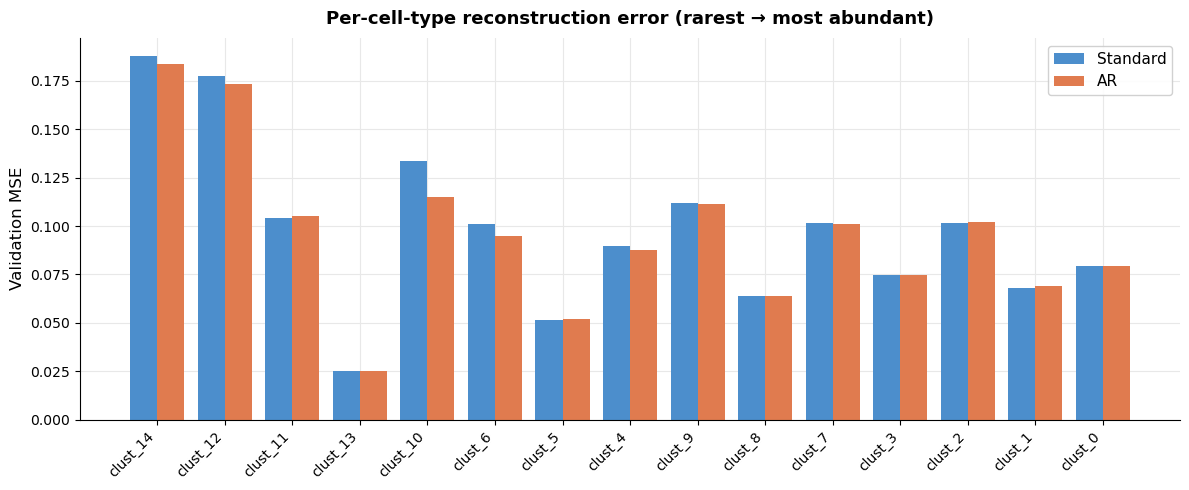

                        Standard      AR  AR improvement (%)
Population avg MSE        0.0803  0.0803              0.0254
Macro avg MSE             0.0981  0.0958              2.2865
Rare-types avg MSE (4)    0.1237  0.1219              1.4399


In [41]:
# Final per-cell-type validation MSE for each model
mse_std = per_celltype_mse(model_std, X_val_t, y_val, device)
mse_ar  = per_celltype_mse(model_ar,  X_val_t, y_val, device)

# order cell types from rarest to most abundant (by training counts)
order = pd.Series(y_train).value_counts().sort_values().index.tolist()
mse_std = mse_std.reindex(order)
mse_ar  = mse_ar.reindex(order)

# ── Bar chart: per-cell-type MSE, Standard vs AR ────────────────────────────
x = np.arange(len(order))
width = 0.4
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, mse_std.values, width, label='Standard', color='#4C8ECC')
ax.bar(x + width / 2, mse_ar.values,  width, label='AR',       color='#E07B4F')
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Validation MSE', fontsize=12)
ax.set_title('Per-cell-type reconstruction error (rarest → most abundant)',
             fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=11, framealpha=0.9, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig('AR_custom_model_per_celltype_mse.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Standard': {
        'Population avg MSE': val_std[-1],
        'Macro avg MSE':      mse_std.mean(),
        f'Rare-types avg MSE ({N_RARE_TYPES})': mse_std.reindex(rare_types).mean(),
    },
    'AR': {
        'Population avg MSE': val_ar[-1],
        'Macro avg MSE':      mse_ar.mean(),
        f'Rare-types avg MSE ({N_RARE_TYPES})': mse_ar.reindex(rare_types).mean(),
    },
})
summary['AR improvement (%)'] = 100 * (summary['Standard'] - summary['AR']) / summary['Standard']
print(summary.round(4).to_string())